# 04 — Residual Encryption with AEAD

After snapping to a 250 m tile, the residual `(rx, ry)` contains the full GPS precision within the tile — up to ±125 m in each axis. If stored in plaintext, an attacker with the tile index (even encrypted) could reconstruct the exact location once they obtain the PRP key.

**<abbr title="Authenticated Encryption with Associated Data — a single operation that both locks data (confidentiality) and produces an authentication tag covering additional unencrypted context (integrity). Any tampering with the ciphertext, nonce, or associated data is detected." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>AEAD (Authenticated Encryption with Associated Data)</strong></abbr>** gives two guarantees:

1. **Confidentiality** — nobody without the key can read `(rx, ry)`.
2. **Integrity** — any modification to the <abbr title="The scrambled, unreadable output produced by encrypting a plaintext with a key. Without the key, a ciphertext reveals nothing about its contents. Here, ct_resid is the encrypted form of the sub-tile residual (rx, ry) plus a 16-byte authentication tag." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">ciphertext</abbr>, <abbr title="A 12-byte value used exactly once per encryption. Ensures that encrypting the same plaintext twice produces different ciphertexts. Reusing a nonce with the same key is catastrophic." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>nonce</strong></abbr>, or associated data is detected and decryption returns `None`.

We use **<abbr title="An AEAD cipher standardised in TLS 1.3 (RFC 8439). ChaCha20 is a stream cipher that encrypts the plaintext; Poly1305 is a MAC that authenticates the ciphertext and associated data." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>ChaCha20-Poly1305</strong></abbr>**, standardised in <abbr title="Transport Layer Security — the security protocol that encrypts data in transit over the internet, responsible for the padlock icon and https:// in web browsers. TLS 1.3 (RFC 8446) mandates ChaCha20-Poly1305 as a required cipher suite, giving this library's AEAD layer well-vetted, standards-backed security properties." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">TLS</abbr> 1.3 (RFC 7539). If the `cryptography` package is absent, the library falls back to <abbr title="XOR (exclusive OR) is a bit-level combining operation. Its defining property is self-cancellation: applying XOR twice with the same value returns the original. Stream ciphers encrypt by XOR-ing plaintext with a secret keystream; the recipient decrypts by XOR-ing with the same keystream. If the keystream is ever reused, an attacker can XOR two ciphertexts together to cancel the key entirely." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">XOR</abbr>+HMAC-SHA256 which provides the same security properties.

The nonce must be **unique per encryption**; reuse with the same key would allow an attacker to XOR two ciphertexts and cancel the keystream entirely. The `encode()` method generates `secrets.token_bytes(12)` for every call.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Pipeline step 3 of 4 — AEAD encryption of the sub-tile residual</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:500;font-size:13px;">① Project</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:500;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#dff0ee;color:#3d7a71;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:500;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Identify** the three components of ChaCha20-Poly1305 — the <abbr title="A cipher is an algorithm (a set of mathematical rules) for transforming plaintext into ciphertext using a key, and back again. The cipher is the method; the ciphertext is the result. A stream cipher applies that transformation continuously, generating a keystream that is combined bit-by-bit with the plaintext — as opposed to a block cipher, which processes fixed-size chunks. ChaCha20 is a stream cipher." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">stream cipher</abbr>, the Poly1305 authenticator, and the associated data field.
2. **Explain** what <abbr title="A formal guarantee that ciphertext leaks no information about plaintext — even to an attacker who can choose which plaintexts to encrypt and compare the resulting ciphertexts." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">semantic security</abbr> guarantees and why a fresh nonce per record is essential for AEAD correctness.
3. **Construct** the length-prefixed associated data string for a given `(qx, qy, tweak)` tuple and verify it prevents boundary-shift attacks.
4. **Analyze** the six tamper scenarios and classify each by the specific authentication failure mode it exercises.
5. **Appraise** which residual threats remain outside the AEAD threat model and require separate mitigations.

![A four-panel comic titled 'Why We Encrypt the Residuals.' Panel 1: A Privacy Engineer (bearded, in Victorian waistcoat) points to a grid diagram showing tile (2,1) highlighted. Published data box shows 'Tile ID: (2,1)'. Caption: 'Tiles protect coarse location.' Shield badge: 'The tile bounds limit an attacker to a 200m x 200m area, not an exact point.' Panel 2: The Epidemiologist (Victorian man) examines the tile with a residual offset marked as (+37m, -42m) — a precise dot inside the tile. Caption: 'Residuals still reveal precision.' Warning badge: 'With (2,1) + (dx,dy), an adversary can pinpoint a specific location within the tile.' Panel 3: The Privacy Engineer gestures toward an encrypted residual box labelled 'A7F3 91C0 B2E6 4D8A...' with a padlock icon. Caption: 'Encrypt residuals to hide precision.' Shield badge: 'Without the key, the residual cannot be recovered or used to refine the location.' Panel 4: Both characters examine the published data showing Tile ID: (2,1) and Encrypted Residual: A7F3 91C0 B2E6 4D8A... together. Caption: 'Precision requires additional protection.' Shield badge: 'Coarse location is useful. Precision remains protected.' Bottom banner with shield and padlock icons: 'Precision requires additional protection. Tiles bound the area. Encryption protects the exact point.'](images/NB04-C1.png)


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import struct    # pack() / unpack() — converts Python numbers into raw bytes and back.
                 # Used here to serialise (rx, ry) as exactly 16 bytes (two 64-bit floats)
                 # before handing them to the cipher for encryption.
import hashlib   # blake2s — a fast cryptographic hash function used in the fallback backend.
import secrets   # Cryptographically secure random byte generator.
                 # secrets.token_bytes(n) draws n bytes from the OS entropy pool —
                 # safe for generating keys and nonces that must be unpredictable.
import numpy as np

# ── Encryption library internals ──────────────────────────────────────────────
# _AEAD            : the AEAD encryption/decryption class (ChaCha20-Poly1305 or fallback).
#                    Instantiated with a 32-byte (256-bit) key; provides .encrypt() and
#                    .decrypt() methods that handle both confidentiality and integrity.
# _build_ad        : assembles the Associated Data (AD) byte string from (qx, qy, tweak),
#                    using a length-prefixed encoding so the byte sequence is unambiguous.
# _CHACHA_AVAILABLE: True if the 'cryptography' package is installed (ChaCha20-Poly1305);
#                    False if the library is using its XOR+HMAC-SHA256 fallback.
# _project         : Stage 1 — forward Web Mercator projection (lat/lon → x/y in metres).
# SchemeParams     : dataclass holding pipeline parameters (bin_size_m=250 m, etc.).
from map_encryption import _AEAD, _build_ad, _CHACHA_AVAILABLE, _project, SchemeParams

# Report which AEAD backend is active so the reader knows which cipher is running.
print(f'AEAD backend: {"ChaCha20-Poly1305 (cryptography)" if _CHACHA_AVAILABLE else "XOR+HMAC-SHA256 (fallback)"}')

params = SchemeParams()
BIN = params.bin_size_m   # tile side length = 250 m (same as NB03)

# Reference coordinate used for all step-by-step demonstrations in this notebook.
CENTER_LAT, CENTER_LON = 51.513341, -0.136668   # Broadwick Street pump, Soho, London

AEAD backend: ChaCha20-Poly1305 (cryptography)


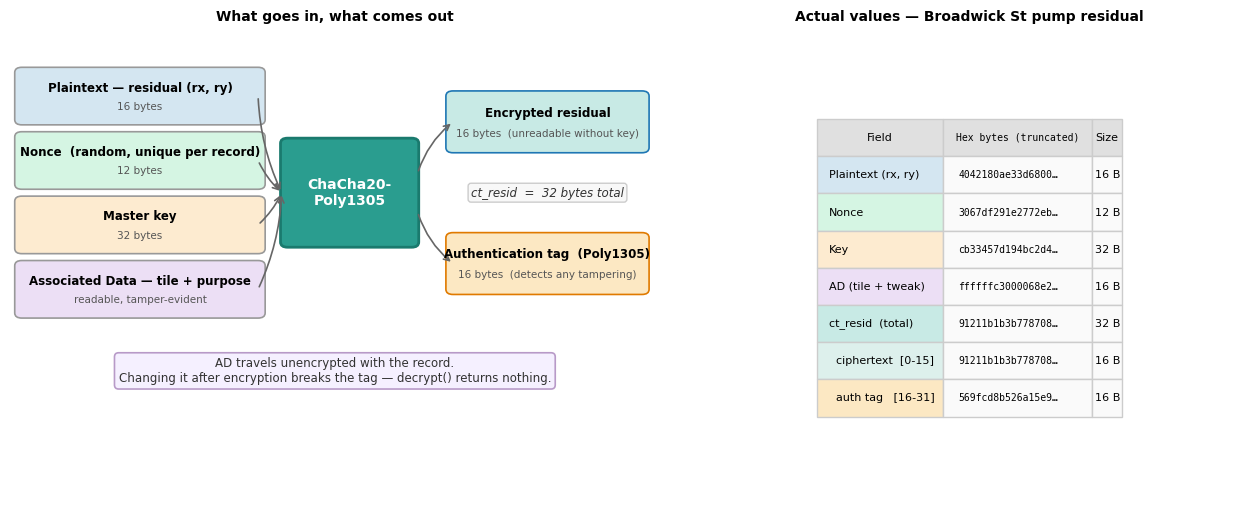

In [2]:
# ── Figure 4a: AEAD encryption pipeline overview ──────────────────────────────
# Structural overview of ChaCha20-Poly1305 AEAD before the detailed code
# demonstrations in the cells that follow.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Compute concrete hex values for the Broadwick Street pump residual.
_fkey   = secrets.token_bytes(32)
_fnonce = secrets.token_bytes(12)
_fx, _fy = _project(CENTER_LAT, CENTER_LON)
_fqx = int(round(_fx / BIN)); _fqy = int(round(_fy / BIN))
_frx = _fx - _fqx * BIN;     _fry = _fy - _fqy * BIN
_fpt = struct.pack('>dd', _frx, _fry)             # 16 bytes: two 64-bit floats
_fad = _build_ad(_fqx, _fqy, b'nb04')
_fct = _AEAD(_fkey).encrypt(_fnonce, _fpt, _fad)  # 32 bytes: 16 ciphertext + 16 tag

fig_diag, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.1, 0.9]})

# ── Left panel: structural diagram ────────────────────────────────────────────
ax_left.axis('off')
ax_left.set_xlim(0, 11); ax_left.set_ylim(0, 11)
ax_left.set_title('What goes in, what comes out', fontsize=10, fontweight='bold', pad=8)

_pal = {'pt': '#d4e6f1', 'nn': '#d5f5e3', 'ky': '#fdebd0',
        'ad': '#ecdff5', 'ct': '#c8eae5', 'tg': '#fce8c3'}

def _aead_box(cx, cy, w, h, top, bot, fc, ec='#999999'):
    ax_left.add_patch(mpatches.FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.12',
        fc=fc, ec=ec, lw=1.2, zorder=2))
    ax_left.text(cx, cy + h * 0.18, top, ha='center', va='center',
                 fontsize=8.5, fontweight='bold', zorder=3)
    ax_left.text(cx, cy - h * 0.22, bot, ha='center', va='center',
                 fontsize=7.5, color='#555555', zorder=3)

_aead_box(2.2, 9.5, 4.0, 1.1, 'Plaintext — residual (rx, ry)', '16 bytes', _pal['pt'])
_aead_box(2.2, 8.0, 4.0, 1.1, 'Nonce  (random, unique per record)', '12 bytes', _pal['nn'])
_aead_box(2.2, 6.5, 4.0, 1.1, 'Master key', '32 bytes', _pal['ky'])
_aead_box(2.2, 5.0, 4.0, 1.1, 'Associated Data — tile + purpose',
          'readable, tamper-evident', _pal['ad'])

for _ayi in [9.5, 8.0, 6.5, 5.0]:
    ax_left.annotate('', xy=(4.6, 7.25), xytext=(4.2, _ayi),
                     arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2,
                                     connectionstyle='arc3,rad=0.1'))

ax_left.add_patch(mpatches.FancyBboxPatch(
    (4.7, 6.1), 2.1, 2.3, boxstyle='round,pad=0.12',
    fc='#2a9d8f', ec='#1a7a6e', lw=2, zorder=2))
ax_left.text(5.75, 7.25, 'ChaCha20-\nPoly1305', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white', zorder=3)

ax_left.annotate('', xy=(7.5, 8.9), xytext=(6.9, 7.7),
                 arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2,
                                 connectionstyle='arc3,rad=-0.15'))
ax_left.annotate('', xy=(7.5, 5.6), xytext=(6.9, 6.8),
                 arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2,
                                 connectionstyle='arc3,rad=0.15'))

_aead_box(9.1, 8.9, 3.2, 1.2,
          'Encrypted residual', '16 bytes  (unreadable without key)',
          _pal['ct'], '#1f77b4')
_aead_box(9.1, 5.6, 3.2, 1.2,
          'Authentication tag  (Poly1305)',
          '16 bytes  (detects any tampering)',
          _pal['tg'], '#e07a00')

ax_left.text(9.1, 7.25, 'ct_resid  =  32 bytes total',
             ha='center', va='center', fontsize=8.5, color='#333333', fontstyle='italic',
             bbox=dict(fc='#f8f8f8', ec='#cccccc', lw=1, boxstyle='round,pad=0.25'))

ax_left.text(5.5, 3.1,
             'AD travels unencrypted with the record.\n'
             'Changing it after encryption breaks the tag — decrypt() returns nothing.',
             ha='center', va='center', fontsize=8.5, color='#333333',
             bbox=dict(fc='#f5f0ff', ec='#b89ac8', lw=1.2, boxstyle='round,pad=0.35'))

# ── Right panel: actual byte values ───────────────────────────────────────────
ax_right.axis('off')
ax_right.set_title('Actual values — Broadwick St pump residual',
                   fontsize=10, fontweight='bold', pad=8)

_tbl_data = [
    ('Plaintext (rx, ry)',     f'{_fpt.hex()[:16]}…',    '16 B'),
    ('Nonce',                  f'{_fnonce.hex()[:16]}…', '12 B'),
    ('Key',                    f'{_fkey.hex()[:16]}…',   '32 B'),
    ('AD (tile + tweak)',      f'{_fad.hex()[:16]}…',    f'{len(_fad)} B'),
    ('ct_resid  (total)',      f'{_fct.hex()[:16]}…',    '32 B'),
    ('  ciphertext  [0-15]',  f'{_fct[:8].hex()}…',     '16 B'),
    ('  auth tag   [16-31]',  f'{_fct[16:24].hex()}…',  '16 B'),
]
_tbl_rc = [
    [_pal['pt'], '#fafafa', '#fafafa'],
    [_pal['nn'], '#fafafa', '#fafafa'],
    [_pal['ky'], '#fafafa', '#fafafa'],
    [_pal['ad'], '#fafafa', '#fafafa'],
    [_pal['ct'], '#fafafa', '#fafafa'],
    ['#ddf0ec',  '#fafafa', '#fafafa'],
    [_pal['tg'], '#fafafa', '#fafafa'],
]
_aead_t = ax_right.table(
    cellText=_tbl_data,
    colLabels=['Field', 'Hex bytes (truncated)', 'Size'],
    cellLoc='left', loc='center',
    cellColours=_tbl_rc,
    colColours=['#e0e0e0', '#e0e0e0', '#e0e0e0'],
)
_aead_t.auto_set_font_size(False)
_aead_t.set_fontsize(8)
_aead_t.auto_set_column_width([0, 1, 2])
_aead_t.scale(1.0, 2.0)
for (_ar, _ac), _acell in _aead_t.get_celld().items():
    _acell.set_edgecolor('#cccccc')
    if _ac == 1:
        _acell.get_text().set_fontfamily('monospace')
        _acell.get_text().set_fontsize(7)

plt.tight_layout(pad=2.0)
plt.show()

**Figure 4a.** ChaCha20-Poly1305 AEAD encryption pipeline for a single health record location. The four inputs (plaintext sub-tile residual, a unique nonce, the master key, and Associated Data encoding the tile and purpose) enter the cipher and produce a 32-byte output `ct_resid`: 16 bytes of encrypted residual followed by a 16-byte Poly1305 authentication tag. The right panel shows actual byte values for the Broadwick Street pump location. The Associated Data (AD) is stored unencrypted and is visible to anyone with database access, but the Poly1305 tag permanently binds the ciphertext to that exact tile and purpose — changing any part of the AD after encryption causes decryption to return nothing.

In [3]:
# ── Semantic security: same plaintext + different nonce = different ciphertext ─
# Goal: demonstrate that encrypting identical data multiple times never produces
# the same ciphertext, so an observer of the encrypted records cannot detect
# when two patients visited the same location.
#
# How it works: ChaCha20 generates a unique keystream from (key, nonce).
# A different nonce → a completely different keystream → a completely different
# ciphertext, even though the underlying (rx, ry) values are identical.
# This is the IND-CPA guarantee ("indistinguishability under chosen-plaintext attack").

# Create a fresh AEAD cipher instance with a random 256-bit (32-byte) key.
# In production, this key is the master key held by the authorised custodian.
aead = _AEAD(secrets.token_bytes(32))

# Pack the synthetic residual (rx=42.5 m, ry=-8.3 m) as 16 raw bytes.
# '>dd' means: big-endian byte order, two 64-bit double-precision floats.
# struct.pack() is used because the cipher operates on bytes, not Python floats.
pt = struct.pack('>dd', 42.5, -8.3)

# Generate three independent 12-byte (96-bit) nonces from the OS entropy pool.
# Each call to encrypt() in a real system uses a fresh nonce via secrets.token_bytes(12).
# 96 bits of randomness means the chance of two nonces ever colliding is negligible
# even across billions of records (birthday probability ≈ 1 in 10^17 after 10^9 records).
nonces = [secrets.token_bytes(12) for _ in range(3)]

# Encrypt the same plaintext three times, each with a different nonce.
# b'' is the associated data — left empty here to isolate the nonce effect;
# real records use _build_ad(qx, qy, tweak) as the associated data.
ciphertexts = [aead.encrypt(n, pt, b'') for n in nonces]

print('3 encryptions of the same plaintext (rx=42.5, ry=-8.3):')
for i, ct in enumerate(ciphertexts):
    print(f'  ct[{i}] = {ct.hex()[:32]}...')   # show only first 16 bytes for readability

# Verify all three ciphertexts are distinct — same plaintext, three different outputs.
assert len(set(ct.hex() for ct in ciphertexts)) == 3, 'Ciphertexts should be distinct'

# Verify each ciphertext decrypts back to the original residual.
# aead.decrypt() returns None if authentication fails; returns plaintext bytes if it passes.
for i, (n, ct) in enumerate(zip(nonces, ciphertexts)):
    recovered = aead.decrypt(n, ct, b'')
    assert recovered is not None, f'Decryption {i} returned None unexpectedly'
    # struct.unpack() reverses struct.pack(): converts the 16-byte blob back into two floats.
    rx_r, ry_r = struct.unpack('>dd', recovered)
    assert abs(rx_r - 42.5) < 1e-12 and abs(ry_r + 8.3) < 1e-12   # floating-point equality

print('All 3 decrypt correctly.')
print('Same plaintext + 3 fresh nonces -> 3 independent ciphertexts (semantic security).')

3 encryptions of the same plaintext (rx=42.5, ry=-8.3):
  ct[0] = ced67e63c749f704523e6eafde8271c9...
  ct[1] = b7f173565145072ce07f4d16d6b85265...
  ct[2] = c42095bc9186127358e7b24c6e09efc6...
All 3 decrypt correctly.
Same plaintext + 3 fresh nonces -> 3 independent ciphertexts (semantic security).


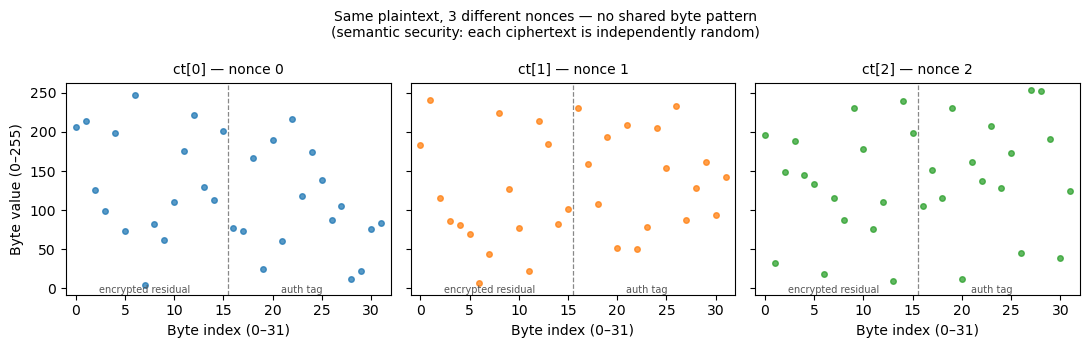

In [4]:
import matplotlib.pyplot as plt

# Three panels: one per ciphertext. Same axes (sharey) so byte-value distributions
# can be compared at a glance. The dashed vertical line separates the encrypted
# residual (bytes 0-15) from the Poly1305 authentication tag (bytes 16-31).
# Seeing three independently scattered clouds with no shared structure is the
# visual proof of semantic security.

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
nonce_labels = [f'ct[{i}] — nonce {i}' for i in range(3)]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

for ax, ct, color, label in zip(axes, ciphertexts, colors, nonce_labels):
    ax.scatter(range(len(ct)), list(ct), color=color, alpha=0.75, s=16)
    ax.axvline(15.5, color='#888888', linewidth=0.9, linestyle='--')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Byte index (0–31)')
    ax.set_xlim(-1, 32)
    ax.set_ylim(-8, 263)
    ax.text(7,  -6, 'encrypted residual', ha='center', fontsize=7, color='#555555')
    ax.text(23, -6, 'auth tag',           ha='center', fontsize=7, color='#555555')

axes[0].set_ylabel('Byte value (0–255)')
fig.suptitle('Same plaintext, 3 different nonces — no shared byte pattern\n'
             '(semantic security: each ciphertext is independently random)',
             fontsize=10)
plt.tight_layout()
plt.show()

**Figure 4b.** Three-panel byte scatter of three ChaCha20-Poly1305 encryptions of the same `(rx, ry)` residual, each using a different 12-byte random nonce. Each panel shows one ciphertext's 32 byte values (0–255) across positions 0–31; the dashed vertical line separates the encrypted residual (bytes 0–15) from the Poly1305 authentication tag (bytes 16–31). The distributions in the three panels share no common structure — confirming *semantic security*: an observer cannot detect when two records encrypt the same location, because each nonce generates an entirely independent ciphertext.

## Associated Data Construction

`_build_ad(qx, qy, tweak)` assembles a short string of bytes that permanently ties an
encrypted residual to the tile it belongs in and the purpose it was encrypted for:

```python
struct.pack('>iiI', qx, qy, len(tweak)) + tweak
```

This byte string contains three values packed in sequence: the tile column `qx` and tile
row `qy` (each stored as a fixed 4-byte integer), the length of the tweak (another 4-byte
integer), and then the tweak itself — a human-readable purpose string such as `b'nb04-demo'`.
The `'>'` in the format string means the integers are written in *network byte order*
(sometimes called *big-endian*): bytes are stored most-significant-first, the same portable
format used across the internet. The exact encoding is an implementation detail; what matters
is that the resulting byte string is **unique for every combination of `(qx, qy, tweak)`**.

**What is the tweak?** The tweak is a short label — a byte string supplied by the caller —
that records the *purpose* or *operational context* of the encryption. In this notebook it
is `b'nb04-demo'`; in the full `encode()` pipeline it encodes the pipeline version and
configuration (e.g. which `SchemeParams` were active at the time of encryption). Its role in
`(qx, qy, tweak)` is to distinguish records encrypted under different operational settings,
even when two records fall in the same tile: a record encrypted under one schema version
cannot be authenticated as if it were produced under a different version, and a record from
one dataset cannot silently substitute for a record from another. The tweak is *not* a
secret — it is included in the Associated Data in plain sight — but it is covered by the
Poly1305 authentication tag, so it cannot be changed after the fact.

**"Authenticated but not encrypted"** means the AD is stored in plain sight alongside the
record — anyone with database read access can see the tile indices and the purpose string.
But the Poly1305 authentication tag is computed over the AD as well as the ciphertext.
Changing even one byte of the AD after encryption causes a tag mismatch.
Think of it as a tamper-evident context seal: the ciphertext is locked, and the spatial
context it was locked *for* cannot be altered without breaking that seal.

**"Rejecting a record"** means `decrypt()` returns `None` and no residual is released —
not a corrupted value, nothing at all. A well-built system treats `None` as a discard
signal: log the failure, stop processing the record, do not use it. This is *fail-closed*
behaviour: a tampered or relocated record produces no output rather than silently
producing incorrect data that could corrupt a disease-cluster map.

**Why prefix the tweak with its length?** Without it, two entirely different input
combinations can accidentally produce the same byte string — a *collision*. A concrete
example: tile `(100, 23)` with tweak `'6'` and tile `(100, 236)` with an empty tweak `''`
could produce identical byte strings if the tweak length were not recorded. A collision
means the authentication tag cannot tell the two apart — an attacker could copy a record
from one tile context into another and authentication would not catch it. Storing
`len(tweak)` before the tweak bytes eliminates this: no two different `(qx, qy, tweak)`
combinations can ever produce the same byte string, regardless of what the tweak
contains or how long it is.


In [5]:
# ── Associated Data construction and boundary-shift attack demo ───────────────
# _build_ad(qx, qy, tweak) produces a byte string that uniquely identifies
# which tile and purpose a ciphertext belongs to. Two different (qx, qy, tweak)
# combinations must always produce different byte strings — if they ever matched,
# an attacker could copy a ciphertext from one tile to another without detection.

# Build AD for two different (qx, qy, tweak) combinations.
# The length-prefix on the tweak ensures these are unambiguous even when
# the raw bytes of qy and tweak happen to overlap in a naive concatenation.
ad1 = _build_ad(100,  23, b'6')    # tile (100, 23),  tweak = '6'
ad2 = _build_ad(100, 236, b'')     # tile (100, 236), tweak = '' (empty)

print(f'_build_ad(100, 23,  b"6") = {ad1.hex()}')
print(f'_build_ad(100, 236, b"")  = {ad2.hex()}')
assert ad1 != ad2, 'AD values should differ'
print('AD values differ: OK')

# ── Boundary-shift attack simulation ─────────────────────────────────────────
# A "boundary-shift attack" attempts to reuse a ciphertext in a different spatial
# context — e.g., copying ct_resid from tile A into a record for tile B.
# The AEAD tag was computed over the original AD (ad1); when decryption
# reconstructs ad2 instead, the tag check fails and None is returned.
demo_aead  = _AEAD(secrets.token_bytes(32))   # fresh key for this demo
demo_nonce = secrets.token_bytes(12)           # fresh 96-bit nonce
demo_pt    = struct.pack('>dd', 10.0, 20.0)   # synthetic residual: rx=10 m, ry=20 m

# Encrypt using ad1 (tile 100, 23) — the tag is now bound to this spatial context.
demo_ct = demo_aead.encrypt(demo_nonce, demo_pt, ad1)

# Attempt to decrypt using ad2 (tile 100, 236) — simulates the attacker moving
# this ciphertext into a different tile's record. The tag cannot verify: None returned.
result = demo_aead.decrypt(demo_nonce, demo_ct, ad2)
assert result is None, 'Expected None for wrong AD'
print('Decryption with mismatched AD returned None: OK')
print('Boundary-shift attack correctly blocked.')

_build_ad(100, 23,  b"6") = 00000064000000170000000136
_build_ad(100, 236, b"")  = 00000064000000ec00000000
AD values differ: OK
Decryption with mismatched AD returned None: OK
Boundary-shift attack correctly blocked.


![A four-panel comic titled with bottom banner 'Coordinates and ciphertext travel together. Changing the spatial context breaks verification.' Panel 1: An adversary (Victorian man in top hat) examines a Public Hotspot Map and a Spatial Record showing Tile ID, Tweak, Version, and ct_resid values. Speech bubble: 'If I move this encrypted residual elsewhere, perhaps it will still decrypt.' Caption: 'Ciphertext alone does not define location.' Panel 2: The adversary pastes the ciphertext into a different tile. Shows Original Coordinates (Tile ID qxp=(14,22)) beside New Tile (Tile ID qxp=(31,08)) with the same ct_resid pasted in and new coordinates. Caption: 'The ciphertext is reused in a new spatial context.' Panel 3: A panel labelled 'AEAD VERIFICATION FAILED — INTEGRITY MISMATCH — Record rejected.' Speech bubble: 'The associated data no longer matches.' Caption: 'Authentication covers more than the ciphertext bytes.' Panel 4: The Privacy Engineer explains a diagram labelled 'BOUND TO CONTEXT' showing three bound components: Tile Coordinates (qxp, qyp), Tweak/Version (any param), and Ciphertext (ct_resid). Speech bubble: 'Change the spatial context, and verification will fail.' Caption: 'Context is part of the contract.'](images/NB04-C3.png)


In [6]:
# ── Six tamper-detection scenarios for a realistic Broadwick Street record ────
# This cell builds a complete encrypted record for the Broadwick Street pump
# location and then attempts six different tamper attacks. Every attack must be
# detected (decrypt returns None). A real system would log or reject any record
# that fails authentication, rather than silently returning bad data.

# ── Step 1: Establish the encryption key ─────────────────────────────────────
# 32 random bytes = 256-bit key — the standard key size for ChaCha20.
# In a deployed system this key is generated once and stored securely;
# only authorised decryptors hold a copy.
test_key = secrets.token_bytes(32)
aead2    = _AEAD(test_key)   # AEAD cipher instance bound to this key

# ── Step 2: Project the pump location and compute the sub-tile residual ───────
# Mirrors Stage 1 (Project) and Stage 2 (Snap) from NB02 and NB03.
x_ts, y_ts = _project(CENTER_LAT, CENTER_LON)   # Web Mercator coordinates (metres)
qx_ts = int(round(x_ts / BIN))                  # tile column index (east–west)
qy_ts = int(round(y_ts / BIN))                  # tile row    index (north–south)
rx_ts = x_ts - qx_ts * BIN                      # east–west  sub-tile offset (metres)
ry_ts = y_ts - qy_ts * BIN                      # north–south sub-tile offset (metres)

# ── Step 3: Build the associated data (spatial + operational context) ─────────
# The AD binds the ciphertext to this specific tile and purpose string.
# Any attempt to move this record to a different tile will produce a different
# AD at decryption time, causing the tag to fail.
nonce_ts = secrets.token_bytes(12)                       # fresh 96-bit nonce
ad_ts    = _build_ad(qx_ts, qy_ts, b'nb04-demo')        # tile indices + purpose string

# ── Step 4: Encrypt the residual ─────────────────────────────────────────────
# struct.pack('>dd', rx, ry) serialises the two floats as 16 raw bytes.
# aead2.encrypt() returns 32 bytes: 16 bytes ciphertext + 16-byte Poly1305 tag.
pt_ts = struct.pack('>dd', rx_ts, ry_ts)
ct_ts = aead2.encrypt(nonce_ts, pt_ts, ad_ts)

# ── Step 5: Six tamper scenarios ──────────────────────────────────────────────
# Each scenario modifies exactly one component of the record and attempts decryption.
# The Poly1305 tag covers all components (ciphertext, nonce, AD), so any single
# modification is sufficient to cause tag verification to fail.
scenarios = [
    # Flip the least-significant bit of the first ciphertext byte.
    # ct_ts[0] ^ 1 applies XOR with 1, toggling the last bit: 0→1 or 1→0.
    # Even a single-bit change anywhere in the 32-byte ciphertext is detected.
    ('Flip ct byte',
     lambda: aead2.decrypt(nonce_ts, bytes([ct_ts[0] ^ 1]) + ct_ts[1:], ad_ts)),

    # Replace the nonce with a fresh random value.
    # ChaCha20 uses the nonce to initialise the keystream; the wrong nonce
    # produces the wrong keystream, so the tag cannot verify.
    ('Change nonce',
     lambda: aead2.decrypt(secrets.token_bytes(12), ct_ts, ad_ts)),

    # Change the tile column index in the AD by +1.
    # Simulates copying this record into a neighbouring tile to the east.
    ('Change qx in AD',
     lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts + 1, qy_ts, b'nb04-demo'))),

    # Change the tile row index in the AD by +1.
    # Simulates copying this record into a neighbouring tile to the north.
    ('Change qy in AD',
     lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts, qy_ts + 1, b'nb04-demo'))),

    # Replace the tweak (purpose string) in the AD.
    # Simulates re-purposing a record from one dataset context to another.
    ('Change tweak in AD',
     lambda: aead2.decrypt(nonce_ts, ct_ts, _build_ad(qx_ts, qy_ts, b'wrong-tweak'))),

    # Use a completely different AEAD key for decryption.
    # The tag was produced with test_key; a different key generates a different
    # expected tag, so verification fails immediately.
    ('Wrong key',
     lambda: _AEAD(secrets.token_bytes(32)).decrypt(nonce_ts, ct_ts, ad_ts)),
]

print(f'{"Scenario":<25} {"Result"}')
print('-' * 40)
all_none = True   # tracks whether every tamper attempt was correctly rejected
for name, fn in scenarios:
    result = fn()
    status = 'PASS (None)' if result is None else 'FAIL (got data!)'
    if result is not None:
        all_none = False
    print(f'  {name:<23} {status}')

assert all_none, 'At least one tamper scenario was not rejected'
print('\nAll 6 tamper scenarios correctly rejected.')

Scenario                  Result
----------------------------------------
  Flip ct byte            PASS (None)
  Change nonce            PASS (None)
  Change qx in AD         PASS (None)
  Change qy in AD         PASS (None)
  Change tweak in AD      PASS (None)
  Wrong key               PASS (None)

All 6 tamper scenarios correctly rejected.


## AEAD Tamper-Detection Results

| Scenario | What was modified | Outcome |
|----------|-------------------|---------|
| Baseline (correct) | (nothing) | ACCEPTED |
| Flip ct byte | First byte of ciphertext | REJECTED |
| Change nonce | Nonce (12-byte random value) | REJECTED |
| Change qx in AD | qx in Associated Data | REJECTED |
| Change qy in AD | qy in Associated Data | REJECTED |
| Change tweak in AD | Tweak in Associated Data | REJECTED |
| Wrong key | Encryption key | REJECTED |

Every modification causes Poly1305 tag verification to fail and `decrypt()` returns `None`.

**Table 4a.** Six tamper-detection scenarios applied to a Broadwick Street pump record encrypted with ChaCha20-Poly1305. Each row changes exactly one component of the record and attempts decryption. In every case `decrypt()` returns `None` — the record is discarded rather than producing corrupted output. This "fail-closed" behaviour means a tampered or relocated record releases no data at all. The baseline scenario (no modification) confirms that a correctly formed record does decrypt successfully.

![A four-panel comic titled 'Why We Prevent and Detect Tampering.' Panel 1: An adversary (Victorian man in top hat, seated at a desk) modifies a ciphertext labelled 'Intercepted Ciphertext (Modified)' with bytes listed. Speech bubble: 'I\'ll change a few bytes and see what happens...' Caption: 'An attacker modifies the ciphertext.' Shield badge: 'Even a tiny change can alter the hidden meaning.' Panel 2: A Privacy Engineer and Epidemiologist examine an AEAD verification panel showing TAG (from data): W 27 A3 10 versus TAG (computed): 6B 81 04 37, with 'VERIFICATION FAILED' in red. Speech bubble: 'The authentication tag doesn\'t match.' Caption: 'The system verifies the AEAD tag. Verification fails.' Shield badge: 'The tag binds the ciphertext and metadata together.' Panel 3: A character states 'Because verification failed, we reject the record.' A record processing panel shows 'REJECTED — No data returned' with a padlock. Caption: 'The system rejects the record. No plaintext is released.' Shield badge: 'Fail closed. Do not decrypt. Do not trust.' Panel 4: Two characters discuss a diagram showing CONFIDENTIALITY + INTEGRITY = TRUSTWORTHY DATA. Speech bubble: 'Confidentiality keeps the data hidden. Integrity ensures it stays truthful.' Caption: 'Tampering is detected, and integrity is preserved.' Shield badge: 'We protect truth as carefully as secrecy.' Bottom banner with shield and padlock icons: 'Integrity matters too. Detect tampering. Reject untrusted data. Protect the truth.'](images/NB04-C2.png)


## What AEAD Does NOT Protect

1. **Does not hide that an encryption happened.** The presence of `ct_resid` in a database is visible to anyone with database read access.

2. **Does not protect `qxp`, `qyp`.** Tile index confidentiality is the PRP's job. AEAD only protects the sub-tile residual.

3. **Nonce reuse is catastrophic.** If the same nonce is ever used twice with the same AEAD key, an attacker can combine the two ciphertexts using XOR (exclusive OR — a self-cancelling bit operation) to eliminate the shared keystream: `ct1 XOR ct2 = pt1 XOR pt2`. The key cancels out entirely, leaving only the XOR of the two plaintexts — from which both original residuals can often be recovered. The `encode()` method generates `secrets.token_bytes(12)` on every call — 96-bit random nonces — making collision probability negligible.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Nir, Y., & Langley, A.** (2018). ChaCha20 and Poly1305 for IETF Protocols. RFC 8439. IETF. https://www.rfc-editor.org/rfc/rfc8439 — Specification for ChaCha20-Poly1305, the AEAD cipher used in this library.
- **Aumasson, J.-P., Neves, S., Wilcox-O'Hearn, Z., & Winnerlein, C.** (2013). BLAKE2: simpler, smaller, fast as MD5. *ACNS 2013*, LNCS 7954, 119–135. https://doi.org/10.1007/978-3-642-38980-1_8 — BLAKE2s is used in the associated data construction and key derivation supporting the AEAD layer.

## Glossary

| Term | Definition |
|------|-----------|
| **AEAD** | Authenticated Encryption with Associated Data; simultaneously encrypts a plaintext and produces an authentication tag that covers both the ciphertext and unencrypted associated data. |
| **Cipher** | An algorithm — a set of mathematical rules — for transforming readable data (plaintext) into scrambled, unreadable data (ciphertext) using a key, and back again. The cipher is the *method*; the ciphertext is the *result*. A **stream cipher** applies the transformation continuously, generating a keystream that is combined bit-by-bit with the plaintext. ChaCha20 is a stream cipher. This is distinct from a **block cipher**, which processes data in fixed-size chunks (e.g. AES). |
| **ChaCha20-Poly1305** | The AEAD cipher used in this scheme; ChaCha20 is a stream cipher providing confidentiality, Poly1305 is a MAC providing integrity and authenticity. |
| **TLS (Transport Layer Security)** | The security protocol that encrypts data transmitted over the internet — responsible for the padlock icon and `https://` in web browsers. TLS 1.3 (the current version) mandates ChaCha20-Poly1305 as a required cipher suite. This library inherits those well-vetted, standards-backed security properties by using the same cipher. |
| **Confidentiality** | The ethical obligation to ensure that sensitive health location data is accessible only to those with explicit authorisation. A breach of confidentiality — whether through a database leak, insider access, or a compromised key — can expose the home addresses of people seeking stigmatised or legally vulnerable health services, enabling discrimination, targeting, or harm. In this scheme, confidentiality means that the sub-tile residual `(rx, ry)` is unreadable without the AEAD key: even an attacker who obtains the encrypted record and the PRP-shuffled tile index cannot reconstruct the exact location. ChaCha20 enforces this guarantee cryptographically. |
| **Integrity** | The ethical obligation to ensure that health records are not silently altered between the point of collection and the point of use. Public health decisions — identifying outbreak sources, directing resources, closing transmission chains — depend on the data being exactly what was originally recorded. A record that has been tampered with, even by a single changed byte, can produce a false disease cluster, erase evidence of an actual outbreak, or shift cases across neighbourhood boundaries in ways that misdirect a public health response. In this scheme, integrity means that any modification to an encrypted record — ciphertext bytes, nonce, or associated data — is detected and the record is rejected rather than silently decrypted. Poly1305 enforces this guarantee via the authentication tag. |
| **Nonce** | A 12-byte value that must be unique per encryption; used to initialise ChaCha20 and included unencrypted in the record. |
| **Plaintext** | The unencrypted residual `(rx, ry)` packed as two 64-bit floats (16 bytes). |
| **Ciphertext (`ct_resid`)** | The scrambled, unreadable output produced by the cipher. Distinct from the cipher itself (the algorithm) — the ciphertext is what that algorithm *produces*. Here, `ct_resid` is the encrypted form of `(rx, ry)`: 16 bytes of encrypted plaintext plus a 16-byte Poly1305 authentication tag (32 bytes total). |
| **Associated Data (AD)** | Context information that travels with an encrypted record but is not itself encrypted — it is readable by anyone, but the AEAD authentication tag guarantees it has not been altered. Changing the AD after encryption causes tag verification to fail and decryption to return `None`. In this scheme, the AD encodes the tile indices `(qx, qy)` and the tweak — the spatial and operational context the ciphertext belongs to. This binding defeats a *ciphertext relocation attack*: if an attacker copies `ct_resid` from one tile into a record for a different tile, the AD reconstructed at decryption time will contain the wrong tile indices, the tag will fail to verify, and the record is rejected outright. AD is distinct from AEAD: AEAD is the name of the combined encryption-plus-authentication technique; AD is the specific unencrypted context field that AEAD authenticates alongside the ciphertext. |
| **Tweak** | A short byte-string label — supplied by the caller — that records the *purpose* or *operational context* of an encryption. In the `(qx, qy, tweak)` triple that forms the Associated Data, `qx` and `qy` identify *where* the record belongs (the tile), and the tweak identifies *for what purpose* or *under which configuration* it was encrypted (e.g. pipeline version, dataset identifier). A record encrypted with one tweak cannot be authenticated as if it were encrypted with a different tweak. The tweak is not a secret — it is stored in plain sight — but it is covered by the Poly1305 tag, so it cannot be silently changed after encryption. |
| **Length-prefixed encoding** | A construction that makes a byte string unambiguous when it is assembled by concatenating multiple fields of variable length. Simply joining raw bytes creates a boundary problem: two different combinations of fields can produce the same byte sequence, undermining authentication. In `_build_ad`, the length of the tweak is stored as a fixed-width integer *before* the tweak bytes — `pack(qx, qy, len(tweak)) + tweak` — so that any combination of `(qx, qy, tweak)` produces a unique sequence. A verifier reading the bytes back can reconstruct the exact original fields without ambiguity, regardless of the tweak content or length. |
| **Authentication tag** | The 16-byte Poly1305 output appended to `ct_resid`; any modification to the ciphertext, nonce, or AD causes tag verification to fail. |
| **IND-CPA** | Indistinguishability under Chosen-Plaintext Attack; the security property ensuring that encryptions of different plaintexts are computationally indistinguishable. |
| **Semantic security** | The property that the ciphertext reveals no partial information about the plaintext; implied by IND-CPA. |
| **Tamper detection** | The ability to detect any modification to `ct_resid`, `nonce`, or AD; provided by the Poly1305 tag with overwhelming probability. |
